In [3]:
import numpy as np
import pandas as pd
import io
import requests

variable         | description
---------------- | -----------     
`score_lit`      | Financial literacy score received after short quiz, out of 50 
`age`            | age of respondant, 18-24, 25-34, 35-44, 45+
`age_of_exp`     | first age of experience with personal finance, 5-11, 11-16, 16+
`score_conf`     | total sum of confidence and behaiviour indicator questions, highest possible sum is 45
`cap_score`      | = 'score_lit' + 'score_conf', highest possible total is 95

In [4]:
import warnings
warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt
import pandas as pd

df = pd.read_csv('LBD.code.csv')

df


,timestamp,score_lit,age,gender,age_of_exp,condition,bnk_sta,fe_exp,pc_disc,fs_inprac,conf_mm,conf_prep,conf_emer,emer_pri,conf_infd,conf_track,plan_largeps,conf_save,conf_goals,score_conf
0,5/19/2026 8:37:23,35,35-44,Female,1,1,1,0,0,0,4,3,5,4,4,4,4,5,4,37
1,5/19/2026 9:26:19,50,35-44,Male,1,0,0,0,0,0,3,4,3,5,2,2,3,3,3,28
2,5/19/2026 9:45:34,30,18-24,Female,0,0,0,0,1,0,4,4,5,5,4,4,4,4,4,38
3,5/19/2026 9:55:12,25,18-24,Female,0,0,0,0,1,0,1,1,1,1,1,2,1,1,1,10
4,5/19/2026 10:07:03,35,18-24,Male,1,1,0,0,1,0,3,3,4,2,3,3,5,4,3,30
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
56,5/21/2026 18:33:47,45,18-24,Female,0,0,0,0,0,0,2,1,3,1,1,4,2,2,2,18
57,5/21/2026 18:38:42,50,25-34,Male,1,0,0,0,1,0,3,3,5,2,2,1,2,5,1,24
58,5/22/2026 22:46:52,30,45+,Female,2,4,0,0,0,0,4,4,3,1,3,5,1,4,4,29
59,5/28/2026 14:28:22,50,18-24,Female,0,0,0,0,1,0,4,4,4,4,4,4,4,4,2,34


In [5]:
# literacy score + confidence/behaiviour score = financial capability score / 'cap_score
df ['cap_score'] = df['score_lit'] + df['score_conf']

df ['cap_score']

0     72
1     78
2     68
3     35
4     65
      ..
56    63
57    74
58    59
59    84
60    53
Name: cap_score, Length: 61, dtype: int64

In [6]:
import numpy as np
import statsmodels.api as sm

#linear reg. 1

formula_string = "score_lit ~ age_of_exp"

model = sm.formula.ols(formula = formula_string, data = df)
model_fitted = model.fit()

print(model_fitted.summary())

                            OLS Regression Results                            
Dep. Variable:              score_lit   R-squared:                       0.045
Model:                            OLS   Adj. R-squared:                  0.028
Method:                 Least Squares   F-statistic:                     2.755
Date:                Fri, 12 Jun 2026   Prob (F-statistic):              0.102
Time:                        16:06:41   Log-Likelihood:                -227.23
No. Observations:                  61   AIC:                             458.5
Df Residuals:                      59   BIC:                             462.7
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     35.0749      1.942     18.064      0.0

In [7]:
import numpy as np
import statsmodels.api as sm
# linear reg. 2
formula_string = "score_conf ~ age_of_exp"

model = sm.formula.ols(formula = formula_string, data = df)
model_fitted = model.fit()

print(model_fitted.summary())

                            OLS Regression Results                            
Dep. Variable:             score_conf   R-squared:                       0.052
Model:                            OLS   Adj. R-squared:                  0.035
Method:                 Least Squares   F-statistic:                     3.204
Date:                Fri, 12 Jun 2026   Prob (F-statistic):             0.0786
Time:                        16:06:41   Log-Likelihood:                -203.26
No. Observations:                  61   AIC:                             410.5
Df Residuals:                      59   BIC:                             414.7
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     29.5106      1.311     22.516      0.0

In [8]:
import numpy as np
import statsmodels.api as sm
#linear reg. 4
formula_string = "cap_score ~ age_of_exp"

model = sm.formula.ols(formula = formula_string, data = df)
model_fitted = model.fit()

print(model_fitted.summary())

                            OLS Regression Results                            
Dep. Variable:              cap_score   R-squared:                       0.077
Model:                            OLS   Adj. R-squared:                  0.062
Method:                 Least Squares   F-statistic:                     4.944
Date:                Fri, 12 Jun 2026   Prob (F-statistic):             0.0300
Time:                        16:06:41   Log-Likelihood:                -242.76
No. Observations:                  61   AIC:                             489.5
Df Residuals:                      59   BIC:                             493.7
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     64.5855      2.505     25.787      0.0

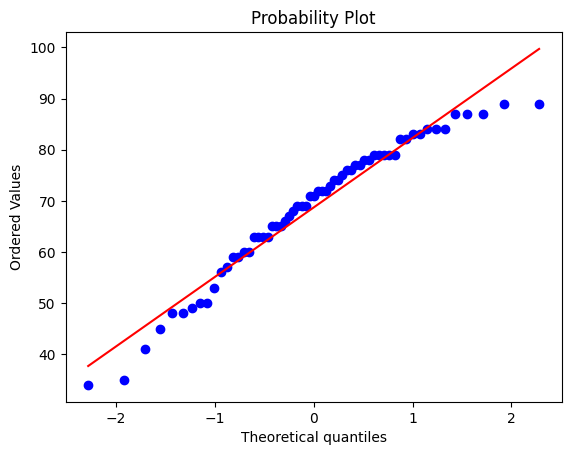

In [9]:
from scipy.stats import probplot
import matplotlib.pyplot as plt

probplot(df['cap_score'], plot = plt)
plt.show();

np.float64(68.70491803278688)

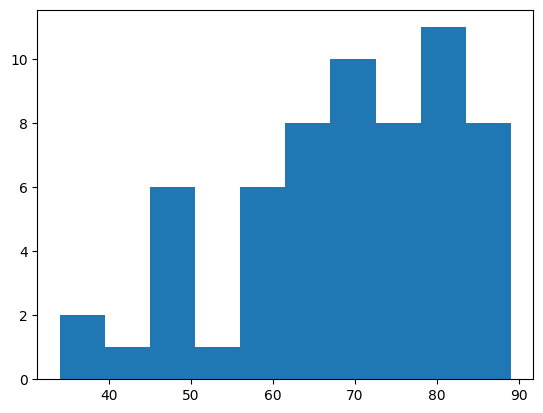

In [10]:
plt.hist(df.cap_score)

df['cap_score'].mean()

np.float64(37.459016393442624)

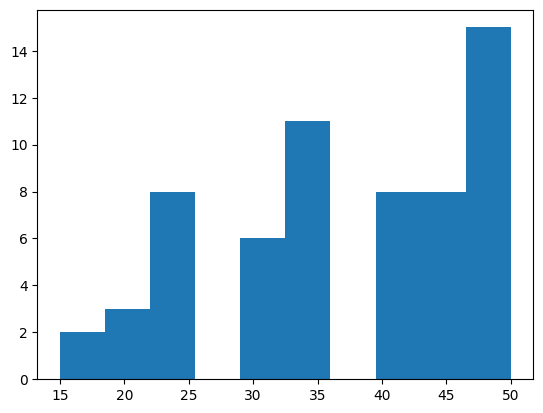

In [11]:
plt.hist(df.score_lit)

df['score_lit'].mean()

np.float64(31.24590163934426)

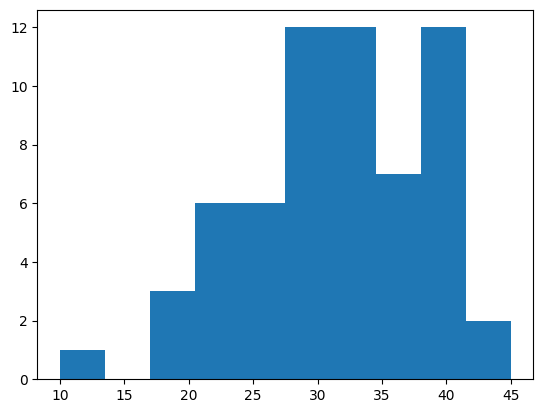

In [12]:
plt.hist(df.score_conf)

df['score_conf'].mean()

np.float64(0.7213114754098361)

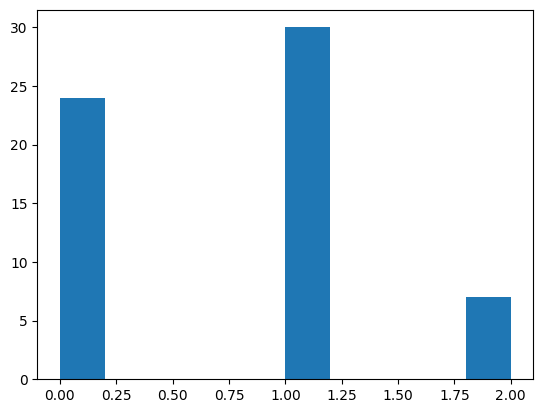

In [13]:
plt.hist(df.age_of_exp)

df['age_of_exp'].mean()

np.float64(0.7868852459016393)

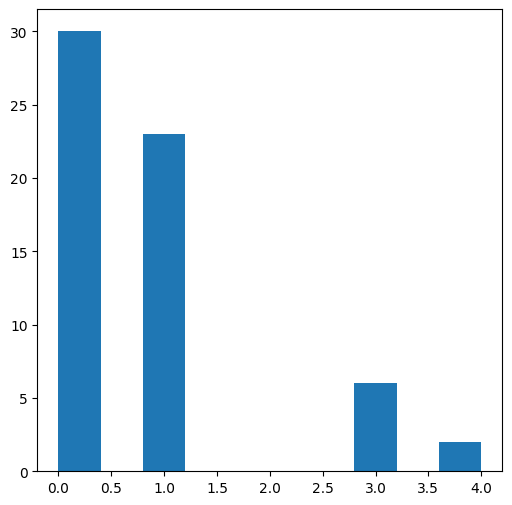

In [29]:
plt.hist(df.condition)
# further variables that arent tested above
df['pc_disc'].mean()

np.float64(0.16393442622950818)

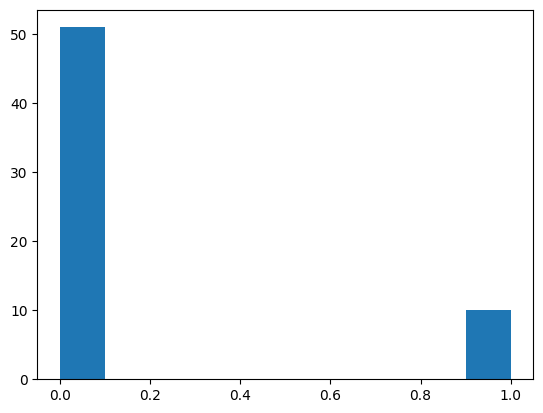

In [15]:
plt.hist(df.bnk_sta)

df['bnk_sta'].mean()

0     0
1     0
2     0
3     0
4     0
     ..
56    0
57    0
58    0
59    0
60    0
Name: fe_exp, Length: 61, dtype: int64

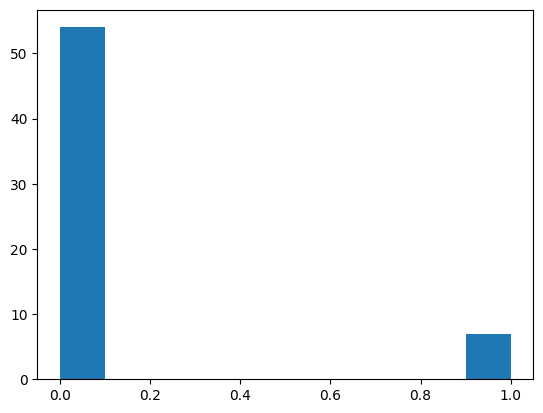

In [16]:
plt.hist(df.fe_exp)

df['fe_exp']

np.float64(0.7868852459016393)

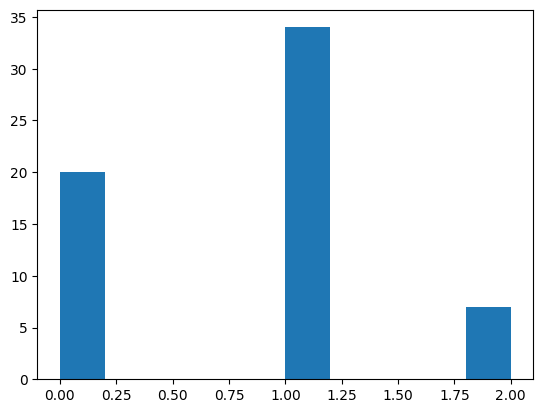

In [17]:
plt.hist(df.pc_disc)

df['pc_disc'].mean()

np.float64(0.4426229508196721)

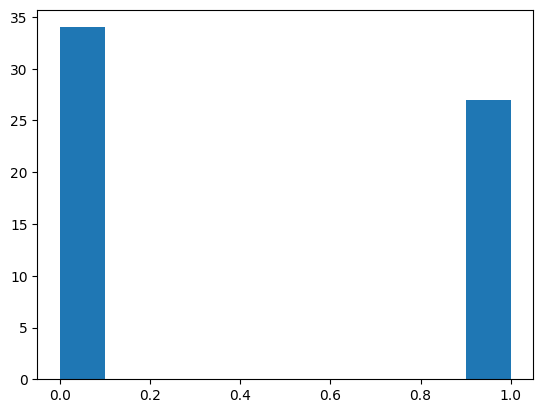

In [18]:
plt.hist(df.fs_inprac)

df['fs_inprac'].mean()

FINANCIAL CONFIDENCE VARIABLES (1-5)

np.float64(3.6557377049180326)

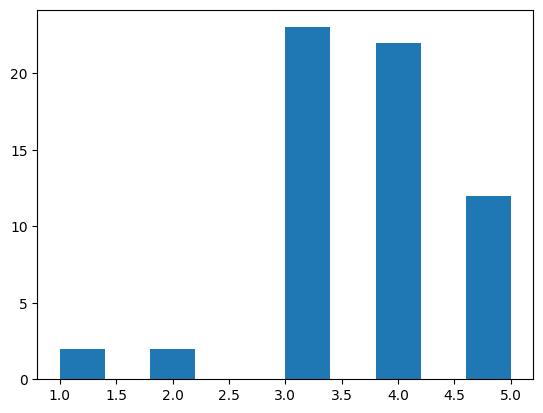

In [19]:
plt.hist(df.conf_mm)

df['conf_mm'].mean()

np.float64(3.3442622950819674)

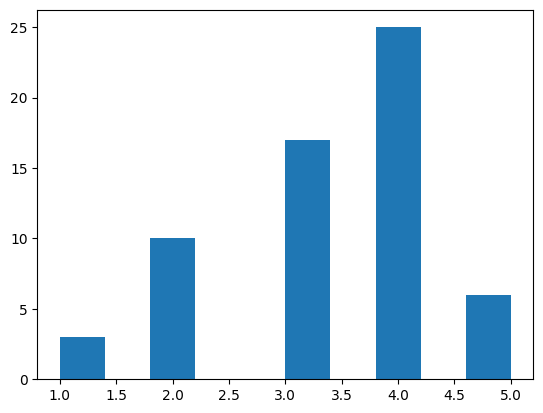

In [20]:
plt.hist(df.conf_prep)

df['conf_prep'].mean()

<bound method Series.mean of 0     5
1     3
2     5
3     1
4     4
     ..
56    3
57    5
58    3
59    4
60    2
Name: conf_emer, Length: 61, dtype: int64>

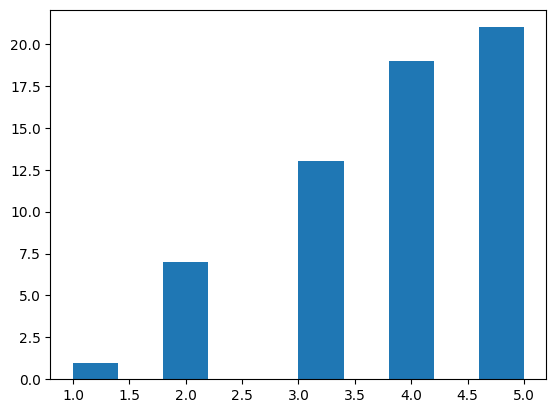

In [21]:
plt.hist(df.conf_emer)

df['conf_emer'].mean

np.float64(2.7540983606557377)

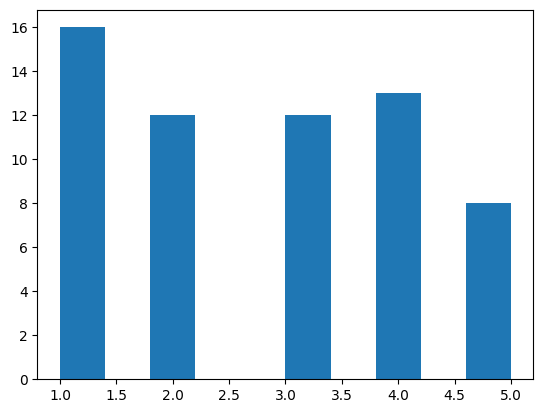

In [22]:
plt.hist(df.emer_pri)

df['emer_pri'].mean()

np.float64(3.6065573770491803)

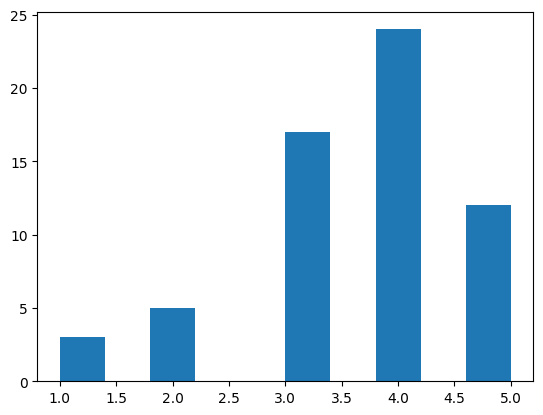

In [23]:
plt.hist(df.conf_infd)

df['conf_infd'].mean()

np.float64(3.622950819672131)

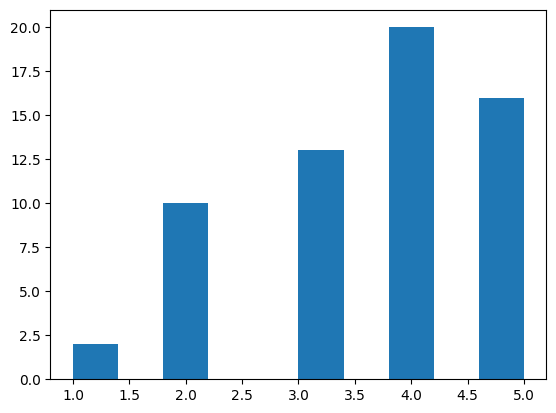

In [24]:
plt.hist(df.conf_track)

df['conf_track'].mean()

np.float64(3.7868852459016393)

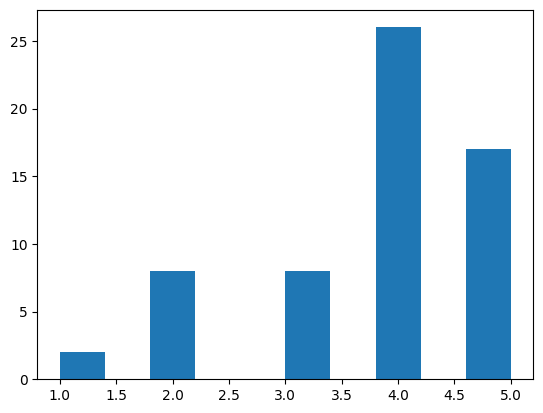

In [25]:
plt.hist(df.plan_largeps)

df['plan_largeps'].mean()

np.float64(3.5901639344262297)

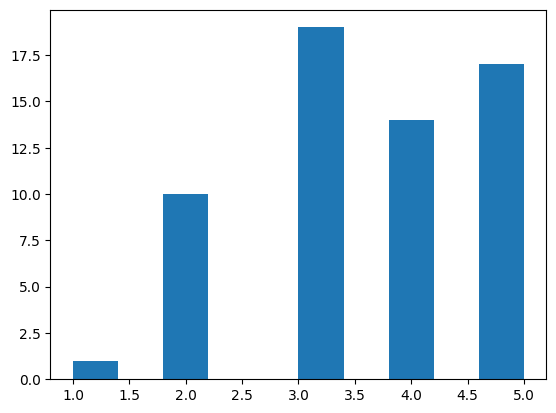

In [26]:
plt.hist(df.conf_save)

df['conf_save'].mean()

<bound method Series.mean of 0     4
1     3
2     4
3     1
4     3
     ..
56    2
57    1
58    4
59    2
60    2
Name: conf_goals, Length: 61, dtype: int64>

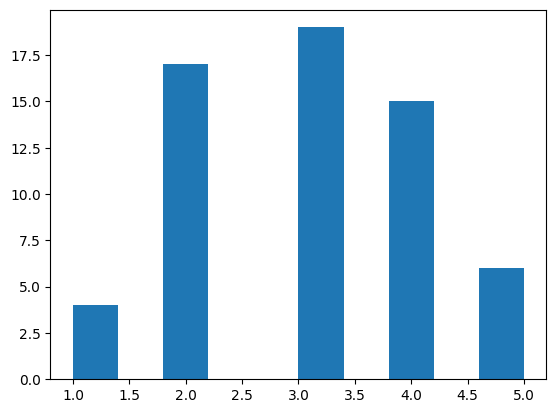

In [27]:
plt.hist(df.conf_goals)

df['conf_goals'].mean

DISPERION

In [28]:
import seaborn as sns
from scipy.stats import norm
import matplotlib.pyplot as plt
%matplotlib inline 
plt.rcParams['figure.figsize'] = (6, 6)

score_hist = sns.distplot(df['score'], norm_hist = True, kde = False, color = 'purple', bins = 8)
x = np.arange(140, 191)                                                  
y = norm.pdf(x, loc = scoremean, scale = scoresd)                                                         
score_hist.plot(x, y, 'purple');

KeyError: 'score'

In [ ]:
from scipy.stats import probplot
import matplotlib.pyplot as plt

probplot(df['score'], plot = plt)
plt.show();

In [ ]:
plt.scatter(df.conf_mm, df.age_of_exp)
plt.xlabel('conf_mm')
plt.ylabel('')

In [ ]:
import seaborn as sns

sns.pairplot(df.iloc[:,12:19])
plt.show();

In [ ]:
plt.scatter(df.score, df.pc_disc)
plt.xlabel('score')
plt.ylabel('pc_disc')
plt.show();

In [ ]:
import matplotlib.pyplot as plt

#prep data
score = df.score
pc_disc = df.pc_disc
# 2. Create Plot
plt.figure(figsize=(8, 5)) # This sets the size of your graph
plt.bar(score,pc_disc , color='black', edgecolor='black')

# 3. Add Details
plt.title('score, parental financial discussion pre16', fontsize=16)
plt.xlabel('score', fontsize=12)
plt.ylabel('pc_disc', fontsize=12)

# 4. Display
plt.show()